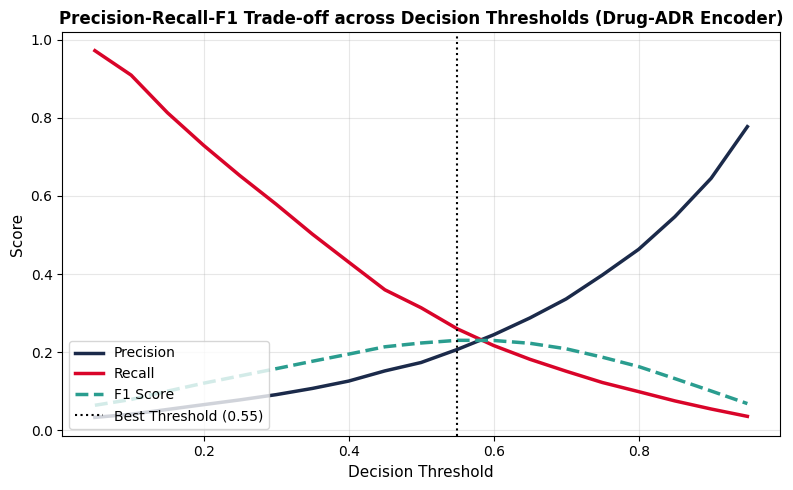

In [1]:
import json
import matplotlib.pyplot as plt

# 1. Load the JSON metadata
json_path = "/Users/duncanpark/10-faers-foundation-model/output/autoencoder/drug_adr_encoder/drug_adr_encoder.json"

with open(json_path, "r") as f:
    data = json.load(f)

# 2. Extract sweep data
sweep = data["final_evaluation"]["threshold_sweep"]
best_thresh = data["final_evaluation"]["best_threshold"]["threshold"]

thresholds = [item["threshold"] for item in sweep]
precisions = [item["precision"] for item in sweep]
recalls = [item["recall"] for item in sweep]
f1s = [item["f1"] for item in sweep]

# 3. Create the Precision-Recall-F1 Trade-off Plot
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions, label="Precision", color="#1b2a4a", lw=2.5)
plt.plot(thresholds, recalls, label="Recall", color="#d90429", lw=2.5)
plt.plot(thresholds, f1s, label="F1 Score", color="#2a9d8f", linestyle="--", lw=2.5)

plt.axvline(
    x=best_thresh, 
    color="black", 
    linestyle=":", 
    label=f"Best Threshold ({best_thresh:.2f})"
)

plt.xlabel("Decision Threshold", fontsize=11)
plt.ylabel("Score", fontsize=11)
plt.title("Precision-Recall-F1 Trade-off across Decision Thresholds (Drug-ADR Encoder)", fontsize=12, fontweight="bold")
plt.legend(loc="lower left")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save image
plt.savefig("/Users/duncanpark/10-faers-foundation-model/output/autoencoder/drug_adr_encoder/tradeoff_plot.png", dpi=300)
plt.show()